In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv(
    "../data/processed/featured_superstore.csv",
    parse_dates=["Order Date", "Ship Date"]
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Shipping Days,Year,Month,Month Name,Quarter,Day Name,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,3,2016,11,November,4,Tuesday,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,3,2016,11,November,4,Tuesday,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,4,2016,6,June,2,Sunday,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,7,2015,10,October,4,Sunday,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,7,2015,10,October,4,Sunday,11.25


# What is the total sales of the company?

In [34]:
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 2297200.8603000003


# How many orders were placed?

In [35]:
total_orders = df["Order ID"].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


# What is the average sales per order?

In [36]:
# total sales
total_sales = df["Sales"].sum()

# TOtal unique orders 
total_orders = df["Order ID"].nunique()

# Average Sales Per Order = Total Sales / Total Orders

avg_sales_per_order = total_sales / total_orders

print("Average Sales Per Order:",round(avg_sales_per_order,2))

Average Sales Per Order: 458.61


# Which year generated the highest sales?

In [37]:
sales_by_year  = df.groupby("Year")["Sales"].sum()

highest_sales_year = sales_by_year.idxmax()
highest_sales = sales_by_year.max()

print(f"Year with highest Sales : {highest_sales_year}")
print(f"Total Sales : ${highest_sales:,.2f}")

Year with highest Sales : 2017
Total Sales : $733,215.26


# What is the yearly sales trend?

In [38]:
yearly_sales = df.groupby("Year")["Sales"].sum().reset_index()
yearly_sales

,Year,Sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


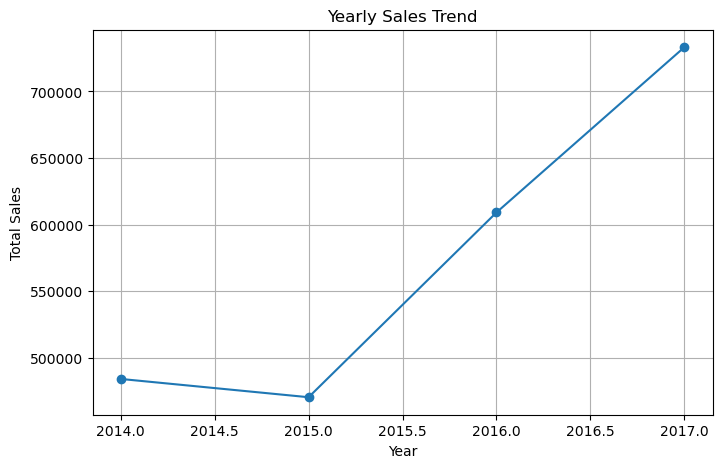

In [39]:
plt.figure(figsize=(8,5))
plt.plot(yearly_sales["Year"], yearly_sales["Sales"], marker="o")

plt.title("Yearly Sales Trend")

plt.xlabel("Year")

plt.ylabel("Total Sales")

plt.grid(True)

plt.savefig(
    "../visualizations/sales/yearly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Question

What is the yearly sales trend?

## Objective

To analyze how sales have changed over different years and identify the company's growth pattern.

## Business Insight

- Sales show an overall increasing trend over the years.
- The highest sales were recorded in the best-performing year.
- This indicates positive business growth.

## Recommendation

- Continue the successful sales strategies.
- Increase investment in marketing and inventory planning.

# Which month has the highest sales?

In [40]:
sales_by_month = df.groupby("Month Name")["Sales"].sum()
highest_sales_month = sales_by_month.idxmax()

highest_sales = sales_by_month.max()

print(f"Month with highest Sales : {highest_sales_month}")
print(f"Total Sales : ${highest_sales:,.2f}")


Month with highest Sales : November
Total Sales : $352,461.07


# Which month has the lowest sales?

In [41]:
sales_by_month = df.groupby("Month Name")["Sales"].sum()
lowest_sales_month = sales_by_month.idxmin()

lowest_sales = sales_by_month.min()

print(f"Month with Lowest Sales : {lowest_sales_month}")
print(f"Total Sales : ${lowest_sales:,.2f}")


Month with Lowest Sales : February
Total Sales : $59,751.25


# What is the monthly sales trend?

In [42]:
monthly_sales = df.groupby(["Month", "Month Name"])["Sales"].sum().reset_index()

monthly_sales = monthly_sales.sort_values("Month")
monthly_sales

,Month,Month Name,Sales
0,1,January,94924.8356
1,2,February,59751.2514
2,3,March,205005.4888
3,4,April,137762.1286
4,5,May,155028.8117
5,6,June,152718.6793
6,7,July,147238.0970
7,8,August,159044.0630
8,9,September,307649.9457
9,10,October,200322.9847


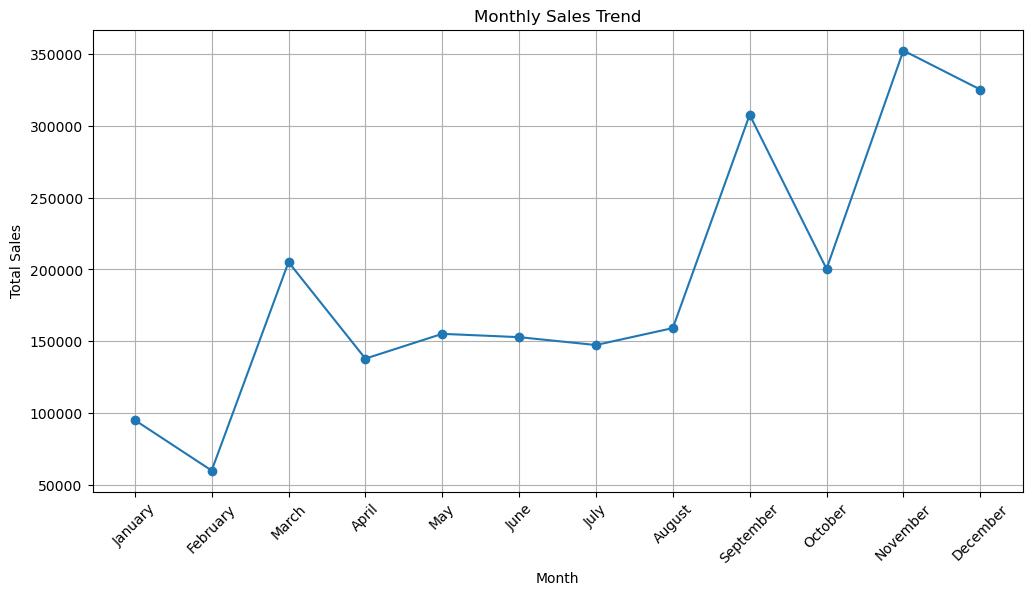

In [43]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales["Month Name"], monthly_sales["Sales"],marker="o")

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.savefig(
    "../visualizations/sales/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Question

What is the monthly sales trend?

## Objective

To identify seasonal sales patterns across different months.

## Business Insight

- Some months generate significantly higher sales.
- Sales fluctuate throughout the year.
- Seasonal demand affects business performance.

## Recommendation

- Increase inventory before high-demand months.
- Launch promotional campaigns during low-sales months.

# Category Analysis

# Which category generated the highest sales?

In [44]:
category_sales = df.groupby("Category")["Sales"].sum().reset_index()
category_sales


,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


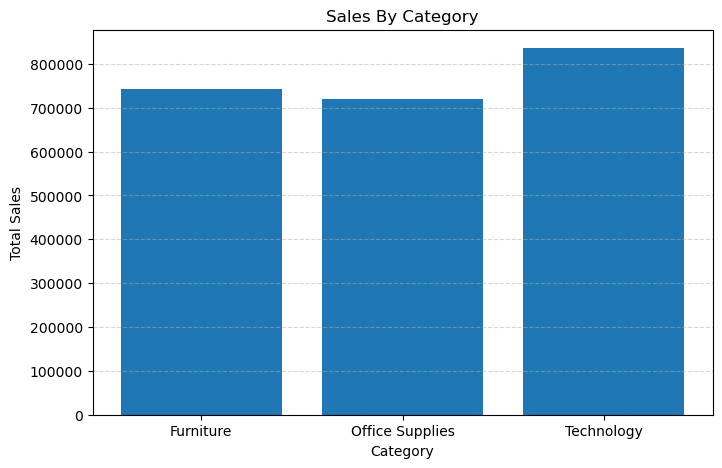

In [45]:
plt.figure(figsize=(8,5))
plt.bar(category_sales["Category"], category_sales["Sales"])

plt.title("Sales By Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../visualizations/sales/category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Sub-Category Analysis

# Top 10 Sub-Categories by Sales

In [70]:
top10_subcategories  = (df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10).reset_index())
top10_subcategories 

,Sub-Category,Sales
0,Phones,330007.0540
1,Chairs,328449.1030
2,Storage,223843.6080
3,Tables,206965.5320
4,Binders,203412.7330
5,Machines,189238.6310
6,Accessories,167380.3180
7,Copiers,149528.0300
8,Bookcases,114879.9963
9,Appliances,107532.1610


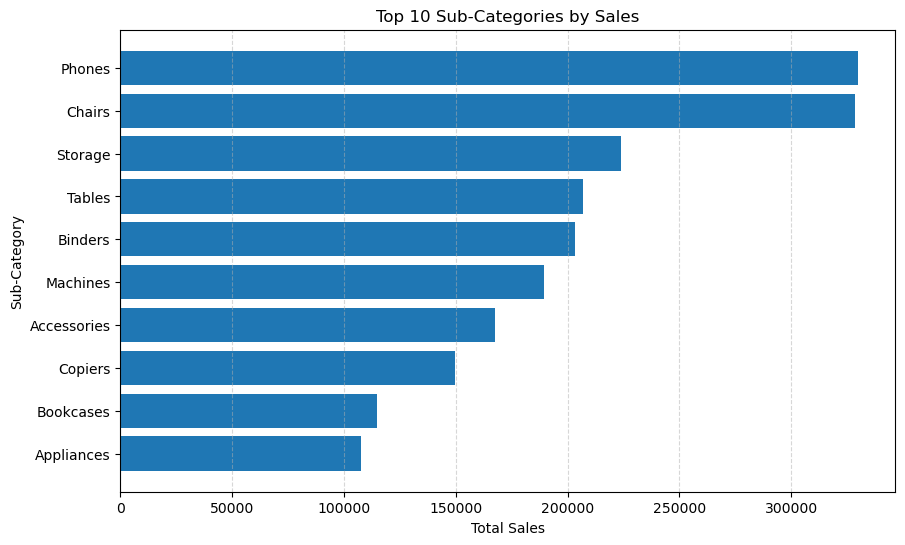

In [72]:
# Horizantal Bar chart
plt.figure(figsize=(10,6))

plt.barh(top10_subcategories["Sub-Category"], top10_subcategories["Sales"])

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.gca().invert_yaxis() # Highest sales at the top

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.savefig(
    "../visualizations/sales/top10_subcategories_sales.png", dpi=300, bbox_inches="tight"
)

plt.show()

## Business Question

Which sub-categories generated the highest sales?

## Objective

To identify the best-selling product sub-categories.

## Business Insight

- A few sub-categories contribute a major share of sales.
- High-performing products should remain available in stock.

## Recommendation

- Maintain sufficient inventory.
- Promote the top-performing sub-categories.

# Regional Analysis

# Which region generated the highest sales?

In [48]:
region_sales  = (df.groupby("Region")["Sales"]).sum().reset_index()
region_sales 

,Region,Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


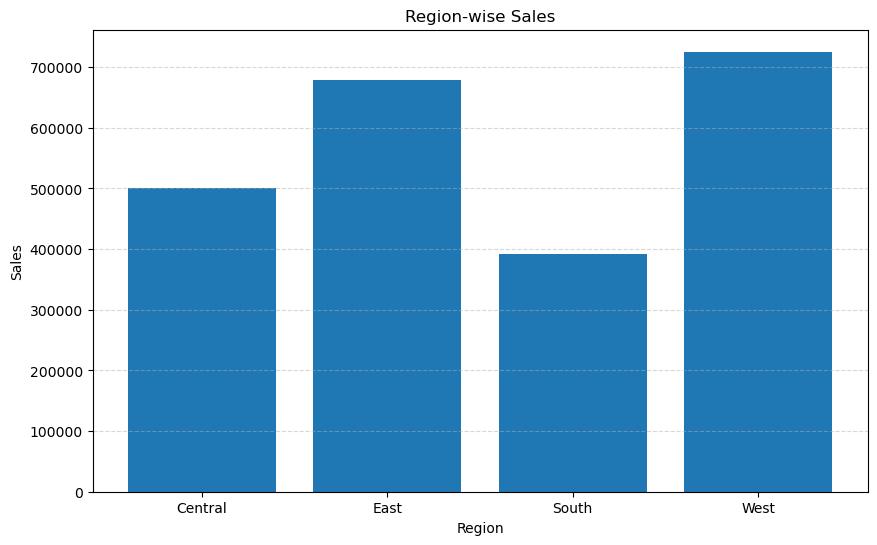

In [49]:
plt.figure(figsize=(10,6))

plt.bar(region_sales ["Region"], region_sales ["Sales"])

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.grid(axis="y", linestyle="--",alpha=0.5)
plt.savefig(
    "../visualizations/sales/region_sales.png", dpi=300, bbox_inches="tight"
)
plt.show()

## Business Question

How much sales did each region generate?

## Objective

To compare sales performance across different regions.

## Business Insight

- Some regions perform significantly better than others.
- Regional demand varies across the business.

## Recommendation

- Expand marketing in low-performing regions.
- Continue investing in high-performing regions.

# Sales by Customer Segment

In [50]:
segment_sales  = (df.groupby("Segment")["Sales"]).sum().reset_index()
segment_sales 

,Segment,Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


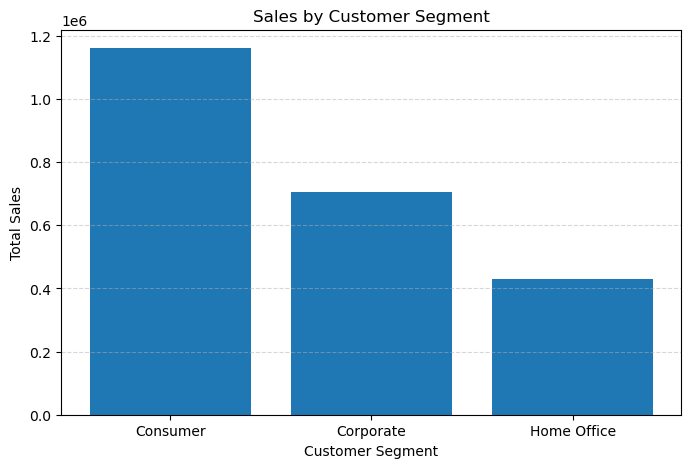

In [51]:
plt.figure(figsize=(8,5))

plt.bar(segment_sales["Segment"], segment_sales["Sales"])

plt.title("Sales by Customer Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Total Sales")

plt.grid(axis="y",linestyle="--", alpha=0.5)

plt.savefig(
    "../visualizations/sales/customer_segment_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ## Business Question

How much sales did each customer segment generate?

## Objective

To compare sales generated by different customer segments.

## Business Insight

- Consumer segment contributes the highest revenue.
- Corporate and Home Office contribute comparatively less.

## Recommendation

- Continue targeting Consumer customers.
- Design offers for Corporate and Home Office customers.

# Top 10 Products by Sales

# Which products generated the highest sales?

In [58]:
top10_products = (df.groupby("Product Name")["Sales"]).sum().sort_values(ascending=False).head(10).reset_index()
top10_products

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


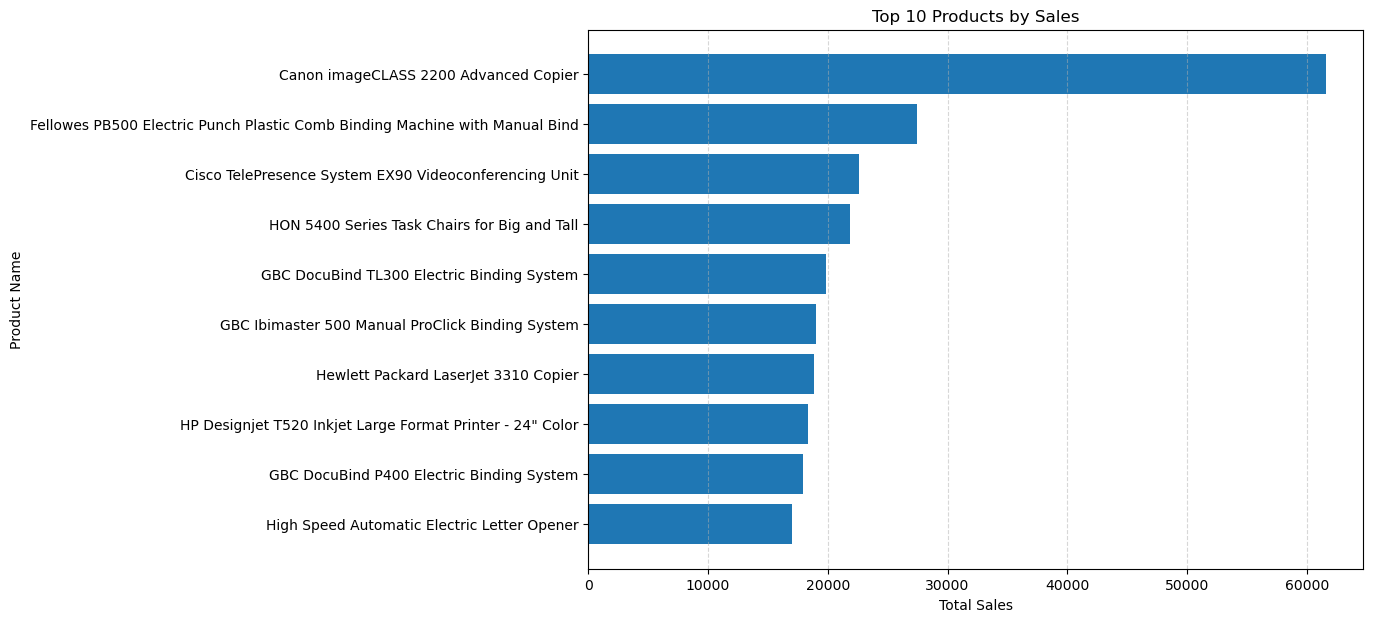

In [62]:
plt.figure(figsize=(10,7))

plt.barh(top10_products["Product Name"], top10_products["Sales"])

plt.title("Top 10 Products by Sales")

plt.xlabel("Total Sales")

plt.ylabel("Product Name")

# Highest sales product top par dikhane ke liye
plt.gca().invert_yaxis()

plt.grid(axis="x",linestyle="--", alpha=0.5)
plt.savefig(
    "../visualizations/sales/top10_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Question

Which products generated the highest sales?

## Objective

To identify the top-selling products.

## Business Insight

- A small number of products generate a large portion of total sales.
- These products are the key revenue drivers.

## Recommendation

- Maintain stock availability.
- Include these products in promotional campaigns.

# Sales by Ship Mode

# How much sales came from each shipping mode?

In [63]:
ship_mode_sales = (df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False).reset_index())
ship_mode_sales 

,Ship Mode,Sales
0,Standard Class,1.358216e+06
1,Second Class,4.591936e+05
2,First Class,3.514284e+05
3,Same Day,1.283631e+05


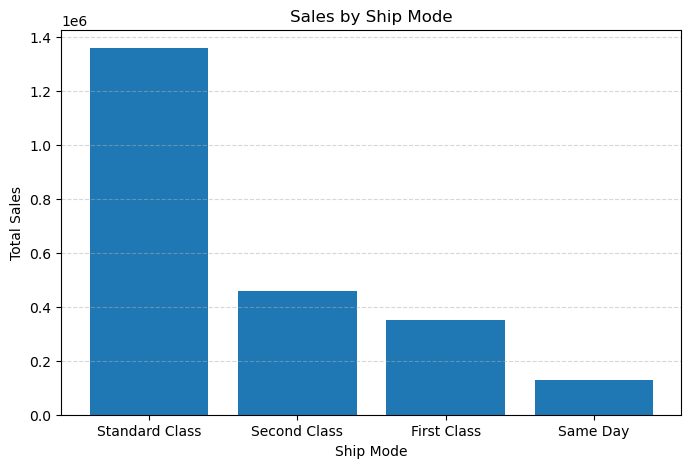

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    ship_mode_sales["Ship Mode"],
    ship_mode_sales["Sales"]
)

plt.title("Sales by Ship Mode")

plt.xlabel("Ship Mode")

plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../visualizations/sales/ship_mode_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Question

How much sales came from each shipping mode?

## Objective

To compare customer preferences for different shipping methods.

## Business Insight

- Standard Class generated the highest sales.
- Same Day shipping contributed the lowest sales.

## Recommendation

- Continue optimizing Standard Class delivery.
- Improve Same Day adoption through discounts or faster service.